In [21]:
import os
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

In [22]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("noopurbhatt/retail-black-friday-sales-dataset")

print("Path to dataset files:", path)
available_files = sorted(os.listdir(path))
available_files

Path to dataset files: C:\Users\FATHIR\.cache\kagglehub\datasets\noopurbhatt\retail-black-friday-sales-dataset\versions\1


['retail_black_friday_sales_100k.csv']

In [23]:
df = pd.read_csv(os.path.join(path, 'retail_black_friday_sales_100k.csv'))

In [24]:
df.rename(columns={'purchase_date': 'date'}, inplace=True)
df['date'] = pd.to_datetime(df['date'])
cols = ['date'] + [col for col in df.columns if col != 'date']
df = df[cols]


df = df.sort_values('date')

df.head()

,date,transaction_id,customer_id,age_group,gender,city,customer_segment,product_id,product_category,original_price,discount_pct,final_price,quantity,purchase_amount,payment_method,purchase_hour,is_weekend,is_black_friday
19438,2025-11-24,T0019439,C009951,26-35,Female,Seattle,Loyal,P8269,Groceries,40.99,35,26.64,1,26.64,Mobile Wallet,17,0,0
16116,2025-11-24,T0016117,C001276,56+,Male,Chicago,Loyal,P3048,Clothing,220.94,25,165.70,1,165.70,Gift Card,21,0,0
16115,2025-11-24,T0016116,C022581,36-45,Female,New York,Returning,P1673,Sports,594.00,20,475.20,1,475.20,Gift Card,4,0,0
32670,2025-11-24,T0032671,C001901,36-45,Other,Dallas,Loyal,P7692,Accessories,449.35,10,404.42,3,1213.26,Debit Card,8,0,0
59257,2025-11-24,T0059258,C020941,18-25,Other,Atlanta,Returning,P1101,Books,17.34,30,12.14,1,12.14,Cash,10,0,0


In [25]:
df.info()

<class 'pandas.DataFrame'>
Index: 100000 entries, 19438 to 0
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   date              100000 non-null  datetime64[us]
 1   transaction_id    100000 non-null  str           
 2   customer_id       100000 non-null  str           
 3   age_group         100000 non-null  str           
 4   gender            100000 non-null  str           
 5   city              100000 non-null  str           
 6   customer_segment  100000 non-null  str           
 7   product_id        100000 non-null  str           
 8   product_category  100000 non-null  str           
 9   original_price    100000 non-null  float64       
 10  discount_pct      100000 non-null  int64         
 11  final_price       100000 non-null  float64       
 12  quantity          100000 non-null  int64         
 13  purchase_amount   100000 non-null  float64       
 14  payment_method    100

In [26]:
start_date = df['date'].min().date()
end_date = df['date'].max().date()
total_days = (end_date - start_date).days

print("\t",15*"="," DATA OVERVIEW ", 15*"=")

overview = pd.DataFrame({
    "Metric": [
        "Date Range",
        "Total Days",
        "Total Transactions",
        "Unique Customers",
        "Unique Products",
        "Total Revenue",
        "Average Transaction",
        "Mean Original Price",
        "Mean Final Price",
        "Mean Discount (%)",
        "Max Discount (%)",
        "Mean Quantity",
        "Total Items Sold",
        "Highest Purchase",
        "Lowest Purchase"
    ],
    "Value": [
        f"{start_date} -> {end_date}",
        total_days,
        len(df),
        df['customer_id'].nunique(),
        df['product_id'].nunique(),
        round(df['purchase_amount'].sum(), 2),
        round(df['purchase_amount'].mean(), 2),
        round(df['original_price'].mean(), 2),
        round(df['final_price'].mean(), 2),
        round(df['discount_pct'].mean(), 2),
        df['discount_pct'].max(),
        round(df['quantity'].mean(), 2),
        df['quantity'].sum(),
        round(df['purchase_amount'].max(), 2),
        round(df['purchase_amount'].min(), 2)
    ]
})

overview


	 ===============  DATA OVERVIEW  ===============


,Metric,Value
0,Date Range,2025-11-24 -> 2025-12-01
1,Total Days,7
2,Total Transactions,100000
3,Unique Customers,32997
4,Unique Products,9000
5,Total Revenue,35125630.67
6,Average Transaction,351.26
7,Mean Original Price,330.28
8,Mean Final Price,242.22
9,Mean Discount (%),26.63


In [27]:
missing_summary = (
    df.isna()
      .sum()
      .reset_index(name='missing_count')
      .rename(columns={'index': 'column'})
)

missing_summary['missing_pct'] = (
    missing_summary['missing_count'] / len(df) * 100
)

missing_summary = missing_summary.sort_values(
    'missing_pct',
    ascending=False
)

missing_summary

,column,missing_count,missing_pct
0,date,0,0.0
1,transaction_id,0,0.0
2,customer_id,0,0.0
3,age_group,0,0.0
4,gender,0,0.0
5,city,0,0.0
6,customer_segment,0,0.0
7,product_id,0,0.0
8,product_category,0,0.0
9,original_price,0,0.0


In [28]:
numerical_cols = [
    'original_price',
    'discount_pct',
    'final_price',
    'quantity',
    'purchase_amount',
    'purchase_hour'
]

outlier_summary = []

for col in numerical_cols:

    series = df[col].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (series < lower_bound) |
        (series > upper_bound)
    ).sum()

    outlier_summary.append({
        'column': col,
        'count': len(series),
        'mean': round(series.mean(), 2),
        'median': round(series.median(), 2),
        'min': round(series.min(), 2),
        'max': round(series.max(), 2),
        'iqr_lower_bound': round(lower_bound, 2),
        'iqr_upper_bound': round(upper_bound, 2),
        'outlier_count': outlier_count,
        'outlier_pct': round(outlier_count / len(series) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.sort_values(
    'outlier_pct',
    ascending=False
)

,column,count,mean,median,min,max,iqr_lower_bound,iqr_upper_bound,outlier_count,outlier_pct
0,original_price,100000,330.28,180.22,5.00,2499.89,-280.27,702.10,11819,11.82
2,final_price,100000,242.22,129.49,2.07,2374.90,-214.01,524.53,11476,11.48
4,purchase_amount,100000,351.26,161.15,2.22,11441.80,-348.71,783.18,10897,10.90
3,quantity,100000,1.45,1.00,1.00,5.00,-0.50,3.50,3979,3.98
1,discount_pct,100000,26.63,25.00,5.00,60.00,-2.50,57.50,1997,2.00
5,purchase_hour,100000,11.48,11.00,0.00,23.00,-13.00,35.00,0,0.00


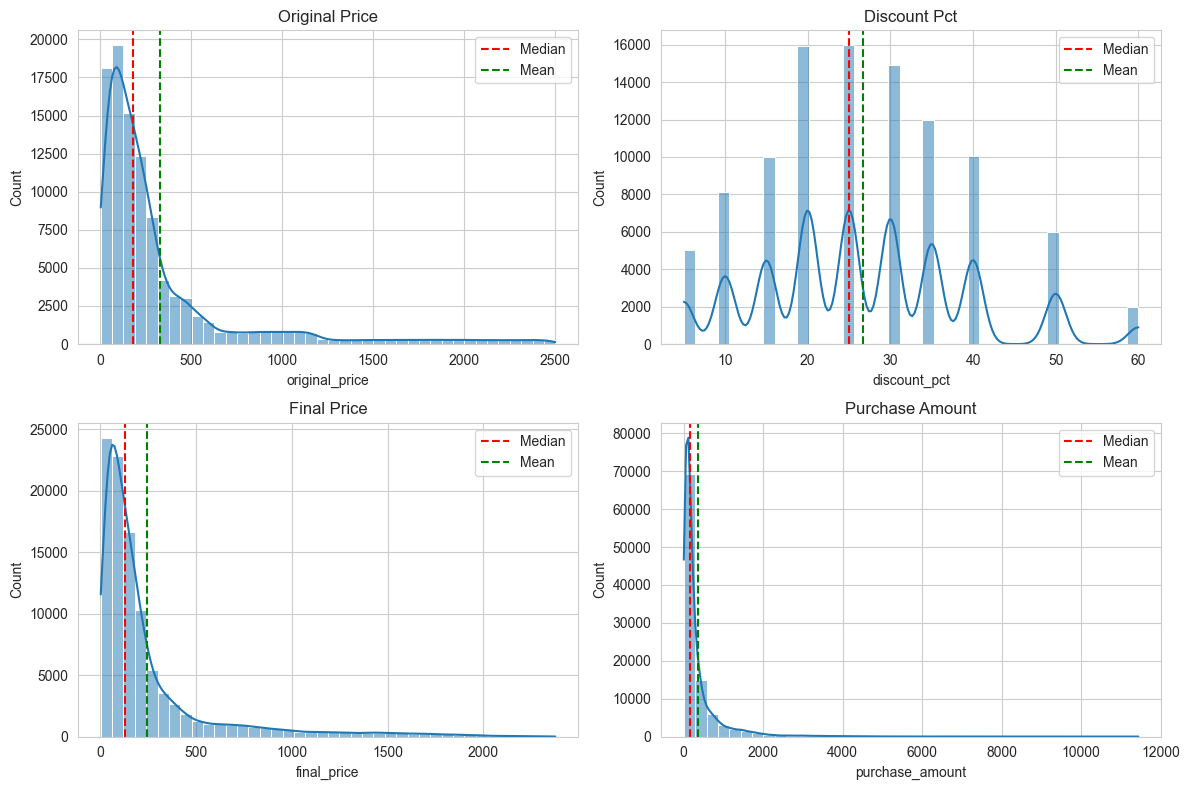

In [29]:
target_columns = [
    'original_price',
    'discount_pct',
    'final_price',
    'purchase_amount'
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, target_columns):

    sns.histplot(
        df[col],
        bins=40,
        kde=True,
        ax=ax
    )

    ax.axvline(
        df[col].median(),
        color='red',
        linestyle='--',
        label='Median'
    )

    ax.axvline(
        df[col].mean(),
        color='green',
        linestyle='--',
        label='Mean'
    )

    ax.set_title(col.replace('_', ' ').title())
    ax.legend()

plt.tight_layout()
plt.show()